In [8]:
# ========================================
# Imports
# ========================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "exploration"
MODEL_DIR = PROJECT_ROOT / "models"

for folder in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURE_DIR,
    MODEL_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project folder:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)

Project folder: /content/drive/MyDrive/SEAID_Framework
Raw data folder: /content/drive/MyDrive/SEAID_Framework/data/raw


In [12]:
!pip install -q kagglehub

In [14]:
import kagglehub
from pathlib import Path
import shutil

In [15]:
download_path = kagglehub.dataset_download(
    "anlgrbz/student-demographics-online-education-dataoulad"
)

download_path = Path(download_path)

print(
    "Kaggle download folder:",
    download_path
)

100%|██████████| 42.2M/42.2M [00:03<00:00, 12.6MB/s]

Extracting files...


Kaggle download folder: /root/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1


In [16]:
import os
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)

def save_figure(filename):
    plt.tight_layout()
    plt.savefig(
        f"../figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [19]:
import platform
print(platform.platform())

Linux-6.6.122+-x86_64-with-glibc2.35


In [20]:
try:
    from google.colab import drive
    print("Google Colab environment detected.")
except ImportError:
    print("This is not Google Colab.")

Google Colab environment detected.


In [21]:
csv_files = list(
    download_path.rglob("*.csv")
)

print(
    f"Found {len(csv_files)} CSV files."
)

for source_file in csv_files:
    destination_file = (
        RAW_DATA_DIR
        / source_file.name
    )

    shutil.copy2(
        source_file,
        destination_file
    )

    print(
        "Copied:",
        source_file.name
    )

Found 7 CSV files.
Copied: studentInfo.csv
Copied: studentRegistration.csv
Copied: courses.csv
Copied: studentAssessment.csv
Copied: assessments.csv
Copied: vle.csv
Copied: studentVle.csv


In [22]:
drive_files = sorted(
    RAW_DATA_DIR.glob("*.csv")
)

for file in drive_files:
    print(file.name)

assessments.csv
courses.csv
studentAssessment.csv
studentInfo.csv
studentRegistration.csv
studentVle.csv
vle.csv


In [24]:
import pandas as pd

student_info = pd.read_csv(
    RAW_DATA_DIR / "studentInfo.csv"
)

student_assessment = pd.read_csv(
    RAW_DATA_DIR / "studentAssessment.csv"
)

student_registration = pd.read_csv(
    RAW_DATA_DIR / "studentRegistration.csv"
)

student_vle = pd.read_csv(
    RAW_DATA_DIR / "studentVle.csv"
)

vle = pd.read_csv(
    RAW_DATA_DIR / "vle.csv"
)

assessments = pd.read_csv(
    RAW_DATA_DIR / "assessments.csv"
)

courses = pd.read_csv(
    RAW_DATA_DIR / "courses.csv"
)

print("All OULAD tables loaded successfully.")

All OULAD tables loaded successfully.


In [25]:
tables = {
    "student_info": student_info,
    "student_assessment": student_assessment,
    "student_registration": student_registration,
    "student_vle": student_vle,
    "vle": vle,
    "assessments": assessments,
    "courses": courses
}

for name, df in tables.items():
    print(
        f"{name}: "
        f"{df.shape[0]:,} rows, "
        f"{df.shape[1]} columns"
    )

student_info: 32,593 rows, 12 columns
student_assessment: 173,912 rows, 5 columns
student_registration: 32,593 rows, 5 columns
student_vle: 10,655,280 rows, 6 columns
vle: 6,364 rows, 6 columns
assessments: 206 rows, 6 columns
courses: 22 rows, 3 columns


In [26]:
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [27]:
# Check the structure of the student information table

student_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [28]:
# Review the column names

student_info.columns.tolist()

['code_module',
 'code_presentation',
 'id_student',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result']

In [29]:
table_summary = pd.DataFrame(
    {
        "table": list(tables.keys()),
        "rows": [df.shape[0] for df in tables.values()],
        "columns": [df.shape[1] for df in tables.values()]
    }
)

table_summary

,table,rows,columns
0,student_info,32593,12
1,student_assessment,173912,5
2,student_registration,32593,5
3,student_vle,10655280,6
4,vle,6364,6
5,assessments,206,6
6,courses,22,3


In [30]:
missing_summary = pd.DataFrame(
    {
        "missing_count": student_info.isna().sum(),
        "missing_percent": (
            student_info.isna().mean() * 100
        ).round(2)
    }
).sort_values(
    by="missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
imd_band,1111,3.41
code_module,0,0.00
id_student,0,0.00
code_presentation,0,0.00
gender,0,0.00
region,0,0.00
highest_education,0,0.00
age_band,0,0.00
num_of_prev_attempts,0,0.00
studied_credits,0,0.00


In [31]:
final_result_counts = (
    student_info["final_result"]
    .value_counts()
)

final_result_counts

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


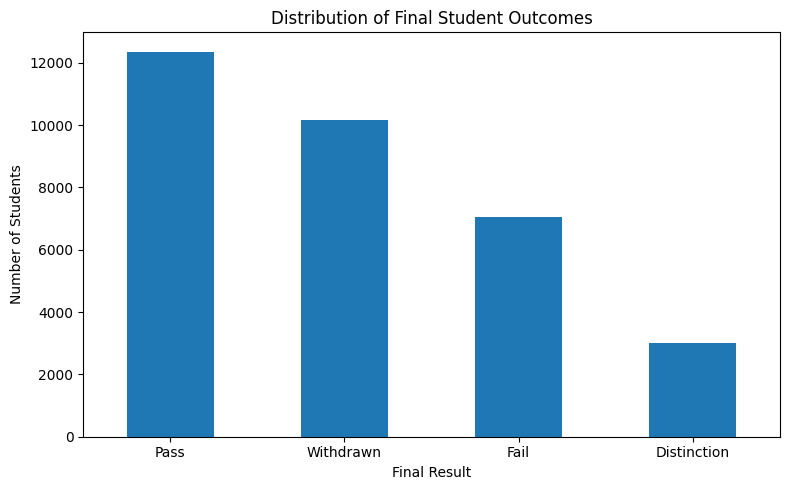

In [32]:
plt.figure(figsize=(8, 5))

final_result_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution of Final Student Outcomes"
)

plt.xlabel("Final Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_figure(
    "final_result_distribution.png"
)